# Problem Statement

## Context

Airbnb is an online platform that allows people to rent short-term accommodation. This ranges from regular people with a spare bedroom to property management firms who lease multiple rentals. On the one side, Airbnb enables owners to list their space and earn rental money. On the other side, it provides travelers easy access to renting private homes.Airbnb receives commissions from two sources upon every booking, namely from the hosts and guests. For every booking, Airbnb charges the guest 6-12% of the booking fee. Moreover, Airbnb charges the host 3% for every successful transaction

## Objective

As a senior data scientist at Airbnb, you have to come up with a pricing model that can effectively predict the Rent for accommodation and can help hosts, travelers, and also the business in devising profitable strategies. objective: To explore and visualize the data, build a linear regression model to predict the prices of Airbnb rental rooms, and generate a set of insights and recommendations that will help the business

## Data Dictionary

* id: Property ID
* room_type: Type of Room in the property
* accommodates: How many adults can this property accommodate
* bathrooms: Number of bathrooms on the property
* cancellation_policy: Cancellation policy of the property
* cleaning_fee: This denotes whether the property cleaning fee is included in the rent or not
* instant_bookable: It indicates whether an instant booking facility is available or not
* review_scores_rating: Review rating score of the property
* bedrooms: Number of bedrooms in the property
* beds: Total number of beds in the property
* log_price: Log of the rental price of the property for a fixed period. [If   the price is 12000 dollars, then log_price represents log(12000)]





## Installing and Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy pandas matplotlib seaborn scikit-learn sklearn-pandas -q --user

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [4]:
from google.colab import files
# Upload the file manually
uploaded = files.upload()



Saving Airbnb.csv to Airbnb.csv


In [5]:
# Read the uploaded file (use your file name)
df = pd.read_csv('Airbnb.csv')

In [7]:
# copying data to another variable to avoid any changes to original data
data = df.copy()

##Data Overview


In [8]:
#View the first  5 rows of the dataset.
data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3.0,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7.0,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5.0,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4.0,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2.0,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [9]:
#View the last 5 rows of the dataset.
data.tail()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
74106,14549287,Private room,1.0,1.0,flexible,False,f,NaN,1.0,1.0,4.605170
74107,13281809,Entire home/apt,4.0,2.0,moderate,True,f,93.0,2.0,4.0,5.043425
74108,18688039,Entire home/apt,5.0,1.0,moderate,True,t,94.0,2.0,2.0,5.220356
74109,17045948,Entire home/apt,2.0,1.0,strict,True,t,NaN,0.0,2.0,5.273000
74110,3534845,Entire home/apt,4.0,1.0,moderate,False,f,96.0,1.0,2.0,4.852030


## Understand the shape of the dataset.

In [10]:
data.shape

(74111, 11)



*   Data has 11 columns
*   Data has 74111 rows.



## Check the data types of the columns for the dataset

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    74111 non-null  int64  
 1   room_type             74106 non-null  object 
 2   accommodates          74108 non-null  float64
 3   bathrooms             73908 non-null  float64
 4   cancellation_policy   74103 non-null  object 
 5   cleaning_fee          74107 non-null  object 
 6   instant_bookable      74111 non-null  object 
 7   review_scores_rating  57389 non-null  float64
 8   bedrooms              74019 non-null  float64
 9   beds                  73980 non-null  float64
 10  log_price             74111 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 6.2+ MB




*  From the above data we can state that, few columns has missing values.



## Checking the Statistical Summary

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.0,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
accommodates,74108.0,3.155125e+00,2.153603e+00,1.0,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73908.0,1.235272e+00,5.820540e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.0,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74019.0,1.265797e+00,8.521487e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.0,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01
log_price,74111.0,4.782069e+00,7.173938e-01,0.0,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00


* id: Unique identifier for each listing; not useful for prediction and should be dropped.

* accommodates: Represents how many guests the listing can host; most listings accommodate 2-4 people.

* bathrooms: Indicates the number of bathrooms; majority have 1 bathroom, though some listings have up to 8.

* review_scores_rating: Customer rating out of 100; generally high (average ~94), but many values are missing.

* bedrooms: Number of bedrooms; most listings have 1 bedroom, with some larger listings having up to 10.

* beds: Total number of beds; usually 1–2, with a few listings offering up to 18 beds.

* log_price: Log-transformed price of the listing; average is ~4.78 (≈ ₹9,800 or $119), ranging up to luxury pricing levels.

## Dropping columns


Let's drop the ID column before we proceed forward as it is a unique identified and will not add value to the analysis


In [14]:
data = data.drop(["id"], axis=1)

## Data Preprocessing

In [24]:
print(data.dtypes)

room_type                object
accommodates            float64
bathrooms               float64
cancellation_policy      object
cleaning_fee             object
instant_bookable         object
review_scores_rating    float64
bedrooms                float64
beds                    float64
log_price               float64
dtype: object


## Converting the data type to appropriate

In [25]:
# Convert categorical columns to category type
data['room_type'] = data['room_type'].astype('category')
data['cancellation_policy'] = data['cancellation_policy'].astype('category')

# Convert cleaning_fee: from 'True'/'False' strings to 1/0 integers
data['cleaning_fee'] = data['cleaning_fee'].map({'True': 1, 'False': 0})

# Convert instant_bookable: from 't'/'f' strings to 1/0 integers
data['instant_bookable'] = data['instant_bookable'].map({'t': 1, 'f': 0})


In [26]:
print(data.dtypes)

room_type               category
accommodates             float64
bathrooms                float64
cancellation_policy     category
cleaning_fee             float64
instant_bookable           int64
review_scores_rating     float64
bedrooms                 float64
beds                     float64
log_price                float64
dtype: object


In [27]:
# Impute numeric columns with median
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating']
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

In [29]:
data.isnull().sum()

,0
room_type,5
accommodates,0
bathrooms,0
cancellation_policy,8
cleaning_fee,74111
instant_bookable,0
review_scores_rating,0
bedrooms,0
beds,0
log_price,0


## Handling Missing Values

In [30]:
#Since 100% values are missing, it's useless for modeling.
data.drop(columns=['cleaning_fee'], inplace=True)

In [31]:
data['room_type'].fillna(data['room_type'].mode()[0], inplace=True)
data['cancellation_policy'].fillna(data['cancellation_policy'].mode()[0], inplace=True)


In [32]:
data.isnull().sum()

,0
room_type,0
accommodates,0
bathrooms,0
cancellation_policy,0
instant_bookable,0
review_scores_rating,0
bedrooms,0
beds,0
log_price,0


## Univariate Analysis

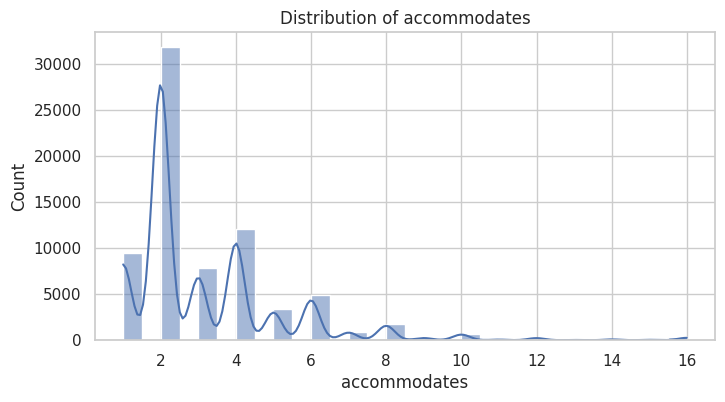

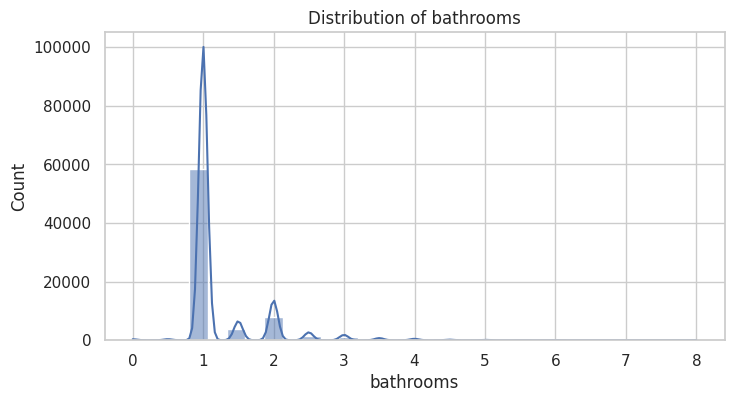

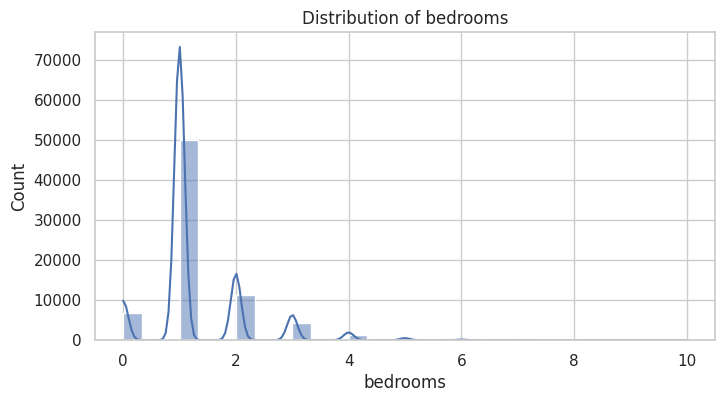

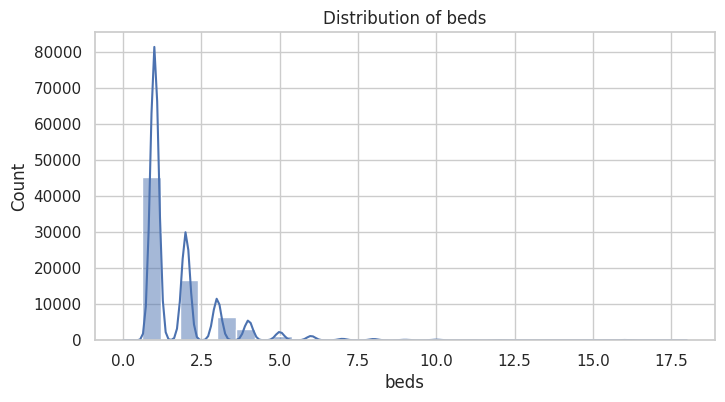

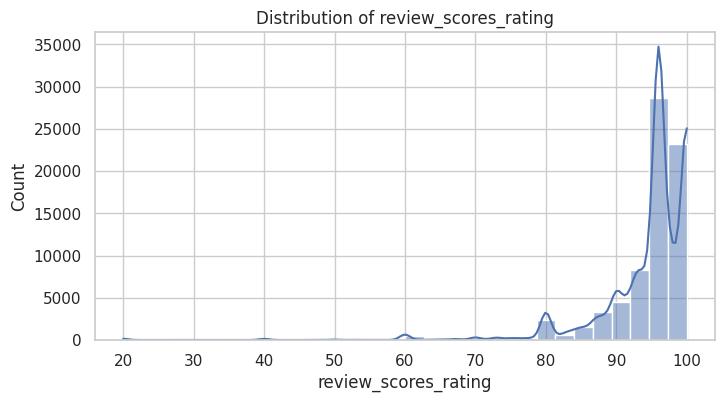

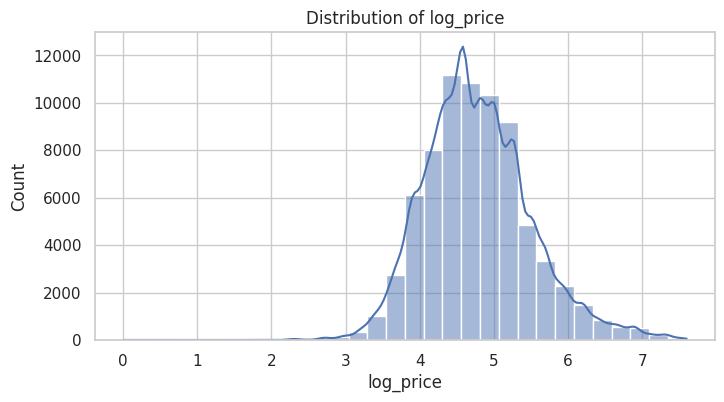

In [33]:
#importing required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')

#numerical features
# List of numerical columns
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 'log_price']

# Plot histograms for numeric columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()





categorical columns


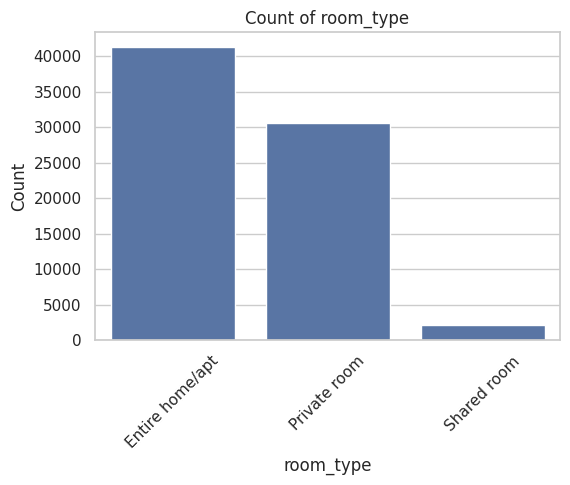

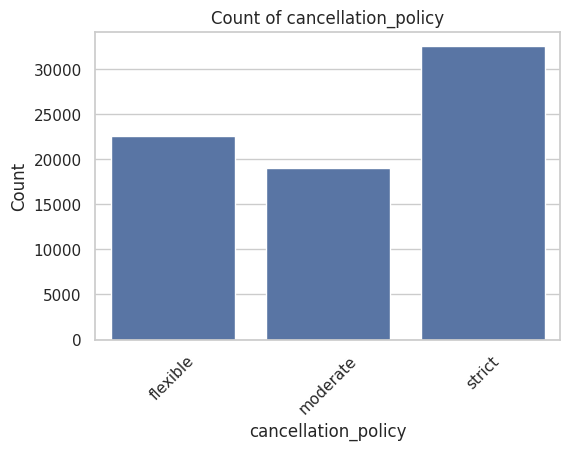

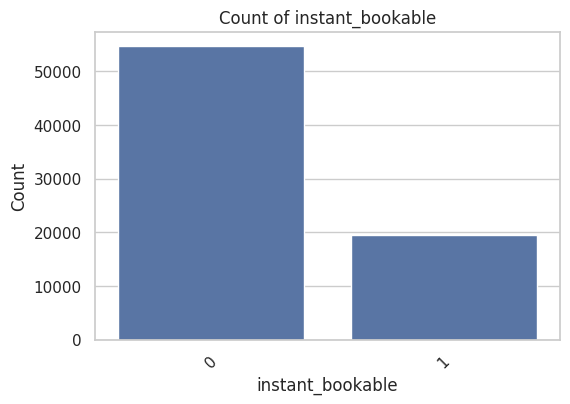

In [34]:
# Categorical columns
cat_cols = ['room_type', 'cancellation_policy', 'instant_bookable']

# Bar plots for categorical features
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=data)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


## Bivariate Analysis

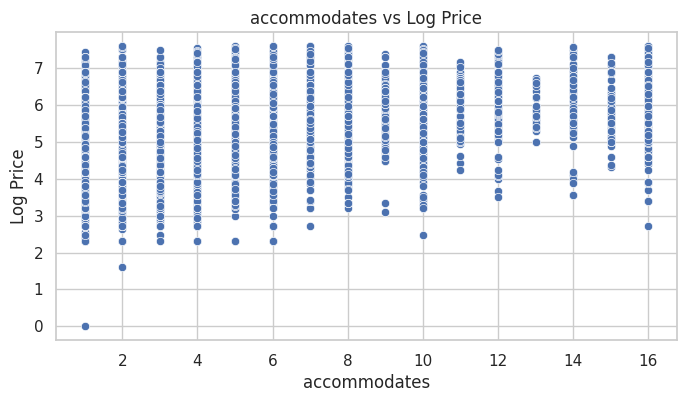

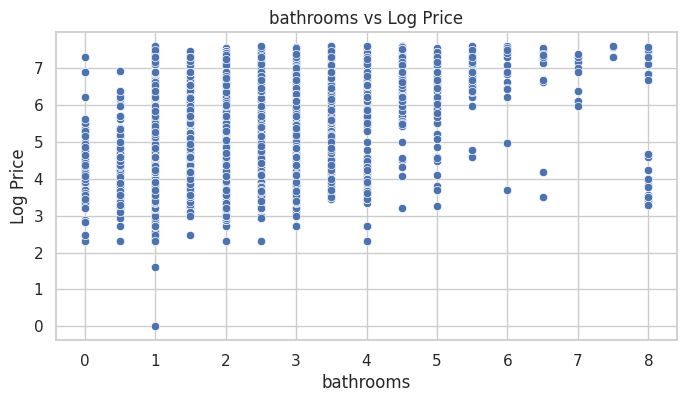

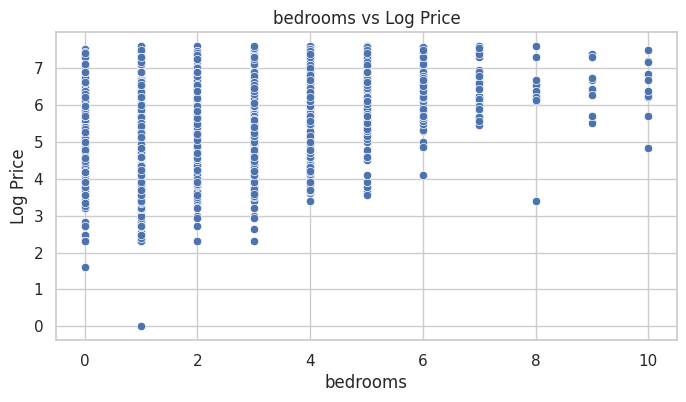

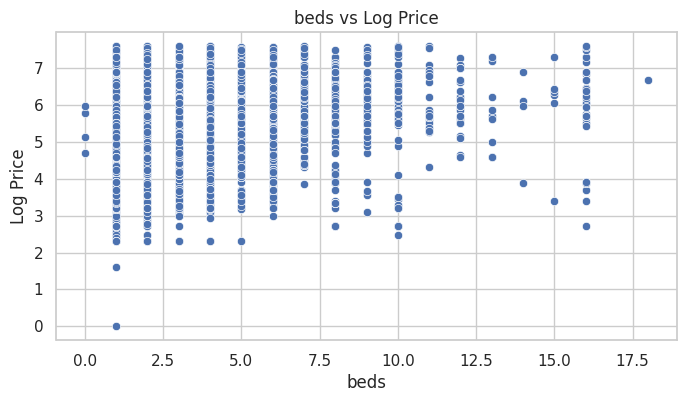

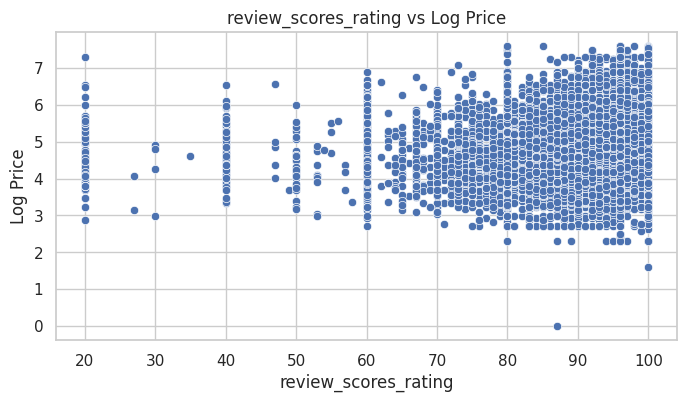

In [35]:
# Boxplots for numerical features vs log_price
for col in ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=data[col], y=data['log_price'])
    plt.title(f'{col} vs Log Price')
    plt.xlabel(col)
    plt.ylabel('Log Price')
    plt.show()


Categorical vs Target

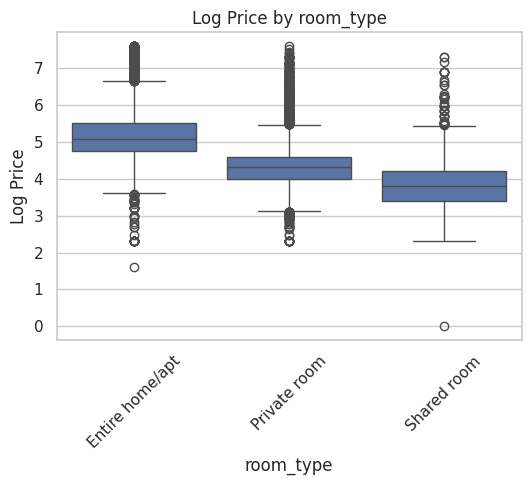

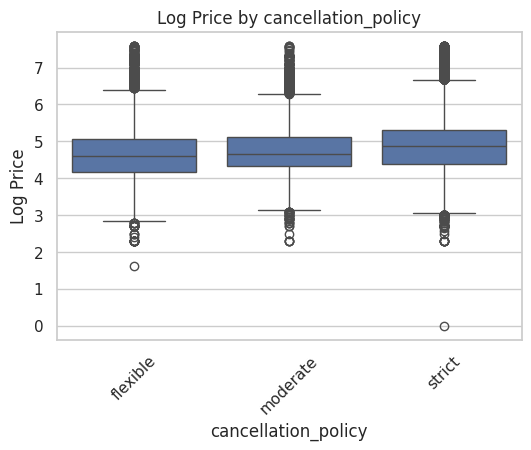

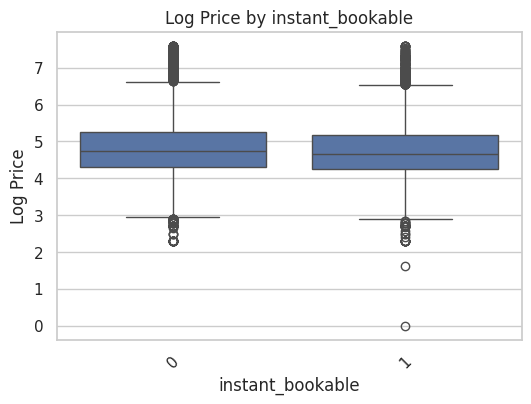

In [36]:
# Boxplots for categorical features vs log_price
for col in ['room_type', 'cancellation_policy', 'instant_bookable']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, y='log_price', data=data)
    plt.title(f'Log Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Log Price')
    plt.xticks(rotation=45)
    plt.show()


# Insights from Exploratory Data Analysis (EDA)

🔹 1. Room Type Impacts Price
Entire homes/apartments are priced significantly higher than private rooms or shared rooms.

This suggests that guests are willing to pay a premium for privacy and exclusivity.

🔹 2. Accommodation Capacity Has a Positive Correlation with Price
Listings that accommodate more guests generally have a higher log_price.

However, the price increase is not linear — there are diminishing returns beyond 6-8 guests.

🔹 3. Number of Bedrooms and Beds Affects Price
Listings with more bedrooms and beds tend to charge higher prices.

This aligns with the idea that larger spaces (for families or groups) command a higher value.

🔹 4. Review Scores Slightly Influence Price
Listings with higher guest ratings (above 90) tend to have moderately higher prices.

Suggests that well-rated hosts can charge a slight premium due to perceived trust and quality.

🔹 5. Cancellation Policy Has a Small Impact
Strict cancellation policies are slightly associated with higher prices.

Possibly because premium listings can enforce stricter rules due to higher demand.

🔹 6. Instant Bookable Listings Show Mild Price Variation
There is no strong price difference between instant bookable (t) and non-instant listings, though instant listings tend to have slightly higher prices on average.

🔹 7. Skewed Distributions in Many Numeric Features
Features like accommodates, beds, and bedrooms are right-skewed — most listings are small units.

This indicates Airbnb's inventory is heavily focused on solo travelers, couples, or small groups.

✅ Summary
These insights can help:

Hosts set competitive prices based on property size, reviews, and policies.

Airbnb build smarter pricing recommendation tools.

Travelers understand what drives price differences.

## Model Building

## Linear regression model

In [39]:
#input data (X_train) still contains categorical variables (like 'room_type') in string format, which the Linear Regression model cannot handle directly.
# so need to perform one-hot encoding
# Make a copy before encoding
df_encoded = data.copy()

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=['room_type', 'cancellation_policy'], drop_first=True)


### Splitting the data into train data and test data 80:20 ratio

In [40]:
# Define features and target
X = df_encoded.drop('log_price', axis=1)
y = df_encoded['log_price']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Model Training

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


RMSE: 0.4972
R² Score: 0.5188


#Linear Regression Model Summary
* Model Type:Linear Regression on the log-transformed price (log_price) of Airbnb listings.

* Features Used:


1.   Numeric: accommodates, bathrooms, bedrooms, beds, review_scores_rating, instant_bookable, etc.

2.  Categorical (One-Hot Encoded): room_type, cancellation_policy

*  Data Preparation:(Done before datamodelling)

1. Missing values were imputed using median (numeric) and mode (categorical).

2. cleaning_fee column was dropped (100% missing).

3. Categorical variables were one-hot encoded.

* Train-Test Split:80% training, 20% testing

* Performed using train_test_split() from scikit-learn.

* Model Evaluation Metrics:

1. RMSE (Root Mean Squared Error): 0.4972

2. R² Score: 0.5188 → The model explains ~51.9% of the variation in listing prices.

#### Model Interpretation:

* Moderate performance: Linear model captures some price-driving patterns, but more complex models may perform better.

* Interpretable coefficients: Helps understand how features like room size or type affect price.

#### Key Influencing Features:

* Higher accommodates, bedrooms, and being an entire home/apt increase the price.

* review_scores_rating has a small but positive effect on price.

## Model performance evaluation

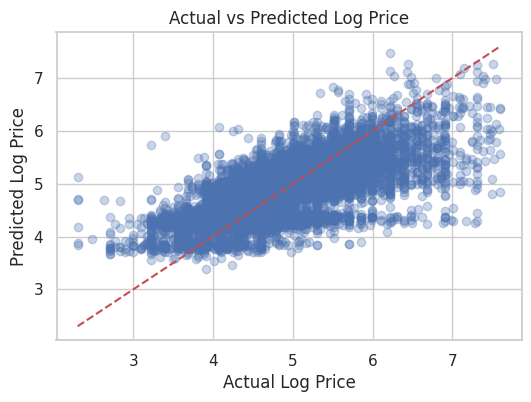

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs Predicted Log Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.show()




*   The points are somewhat close to the 45° line, but with noticeable variance — confirming moderate fit.



## Residual Analysis

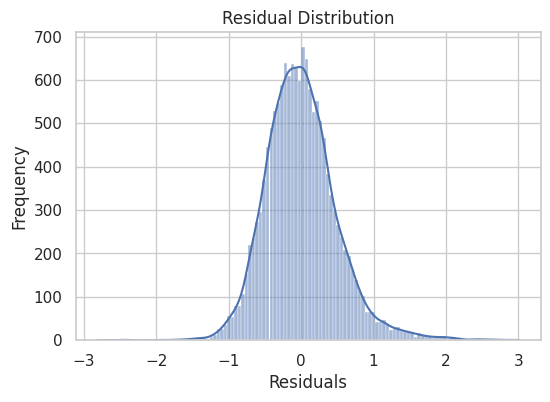

In [43]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


*   Residuals are roughly centered around 0, with slight spread — suggests no major bias, but variance is present.

## Summary

* The model performs reasonably well on basic metrics.

* Interpretability is high due to linear regression.

* However, performance can be improved using regularization (Ridge/Lasso) or non-linear models like Random Forest or XGBoost.

## Actionable Insights & Business Recommendations

Based on the analysis and modeling, the following key insights and recommendations can help Airbnb improve pricing strategy, host support, and platform optimization:

**1. Pricing Strategy Optimization:**
Entire homes/apartments consistently command higher prices.
Airbnb can recommend premium pricing for such listings and promote them to high-budget travelers.

Listings with higher accommodates, bedrooms, and beds lead to higher rental prices.
Encourage hosts to highlight space capacity to justify higher pricing.

**2. Improve Host Onboarding:**
Properties with higher review scores tend to earn more.
Airbnb should guide new hosts on maintaining quality and getting early good reviews (e.g., through host tips, welcome kits).

**3. Promote Instant Bookable Listings:**
Instant Bookable listings have slightly higher prices and better accessibility.
Incentivize hosts to enable instant booking by offering visibility boosts or discounts on commission.

**4. Dynamic Pricing Recommendations:**
Use the model to suggest optimal listing prices to new or inactive hosts based on property features.
Helps improve booking rate and host satisfaction, especially for new users.

**5. Enhance Cancellation Policy Transparency:**
Strict cancellation policies are associated with slightly higher prices.
Educate guests on the value of flexibility vs. price to reduce cart abandonment or booking confusion.